In [1]:
import pandas as pd

df = pd.read_csv('data/cyberbullying_tweets.csv')
df.head()
df['cyberbullying_type'].value_counts()

cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespace
    text = text.strip()
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

df['cleaned_text'] = df['tweet_text'].apply(clean_text)
df.head(10)

[nltk_data] Downloading package stopwords to /home/skol/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/skol/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,tweet_text,cyberbullying_type,cleaned_text
0,"In other words #katandandre, your food was cra...",not_cyberbullying,word food crapilicious
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,white
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,classy whore red velvet cupcake
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,meh p thanks head concerned another angry dude...
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,isi account pretending kurdish account like is...
5,"@Raja5aab @Quickieleaks Yes, the test of god i...",not_cyberbullying,yes test god good bad indifferent weird whatev...
6,Itu sekolah ya bukan tempat bully! Ga jauh kay...,not_cyberbullying,itu sekolah ya bukan tempat bully ga jauh kaya...
7,Karma. I hope it bites Kat on the butt. She is...,not_cyberbullying,karma hope bite kat butt nasty
8,@stockputout everything but mostly my priest,not_cyberbullying,everything mostly priest
9,Rebecca Black Drops Out of School Due to Bully...,not_cyberbullying,rebecca black drop school due bullying


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# 1. Encode the Labels (e.g., 'religion' becomes 0, 'age' becomes 1)
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['cyberbullying_type'])
df.head()

# 2. Split the data (80% training, 20% testing)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_text'], 
    df['label_encoded'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['label_encoded'] # Ensures balance is maintained in split
)

# 3. Vectorize the text
tfidf = TfidfVectorizer(max_features=5000) # We keep the top 5000 most important words
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (38153, 5000)
Testing shape: (9539, 5000)


In [9]:
import pandas as pd

# Let's take the first 5 tweets from the training set and see the math
sample_vector = pd.DataFrame(
    X_train[:5].toarray(), 
    columns=tfidf.get_feature_names_out()
)

# Display columns that actually have values (non-zero) for the first tweet
first_tweet_sample = sample_vector.iloc[0]
print("Words found in the first tweet and their TF-IDF scores:")
print(first_tweet_sample[first_tweet_sample > 0])

Words found in the first tweet and their TF-IDF scores:
ally        0.477711
bad         0.304709
fucking     0.271440
idea        0.371378
lie         0.375890
say         0.253710
see         0.274301
terrible    0.431787
Name: 0, dtype: float64


In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# 2. Train SVM
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

# 3. Print Results
print("--- Naive Bayes Results ---")
print(f"Accuracy: {accuracy_score(y_test, nb_preds)}")
print(classification_report(y_test, nb_preds, target_names=le.classes_))

print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, svm_preds)}")
print(classification_report(y_test, svm_preds, target_names=le.classes_))

--- Naive Bayes Results ---
Accuracy: 0.752280113219415
                     precision    recall  f1-score   support

                age       0.80      0.97      0.87      1598
          ethnicity       0.85      0.91      0.88      1592
             gender       0.83      0.79      0.81      1595
  not_cyberbullying       0.62      0.38      0.47      1589
other_cyberbullying       0.57      0.51      0.54      1565
           religion       0.77      0.94      0.85      1600

           accuracy                           0.75      9539
          macro avg       0.74      0.75      0.74      9539
       weighted avg       0.74      0.75      0.74      9539


--- SVM Results ---
Accuracy: 0.8059545025684034
                     precision    recall  f1-score   support

                age       0.95      0.98      0.96      1598
          ethnicity       0.97      0.97      0.97      1592
             gender       0.86      0.82      0.84      1595
  not_cyberbullying       0.54      

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Train SVM with balanced class weights
svm_balanced = LinearSVC(class_weight='balanced')
svm_balanced.fit(X_train, y_train)
bal_preds = svm_balanced.predict(X_test)

print("--- Balanced SVM Results ---")
print(classification_report(y_test, bal_preds, target_names=le.classes_))



--- Balanced SVM Results ---
                     precision    recall  f1-score   support

                age       0.95      0.98      0.96      1598
          ethnicity       0.97      0.97      0.97      1592
             gender       0.86      0.82      0.84      1595
  not_cyberbullying       0.54      0.53      0.54      1589
other_cyberbullying       0.56      0.59      0.57      1565
           religion       0.95      0.94      0.95      1600

           accuracy                           0.81      9539
          macro avg       0.81      0.81      0.81      9539
       weighted avg       0.81      0.81      0.81      9539



In [12]:
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 2. Random Forest (Warning: This might take a minute to train)
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 3. Passive Aggressive Classifier
pa_model = PassiveAggressiveClassifier(max_iter=1000)
pa_model.fit(X_train, y_train)
pa_preds = pa_model.predict(X_test)

# Quick Accuracy Check
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds)}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds)}")
print(f"Passive Aggressive Accuracy: {accuracy_score(y_test, pa_preds)}")

/home/skol/Desktop/mlc-project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression Accuracy: 0.8099381486528986
Random Forest Accuracy: 0.8022853548589999
Passive Aggressive Accuracy: 0.7831009539784044


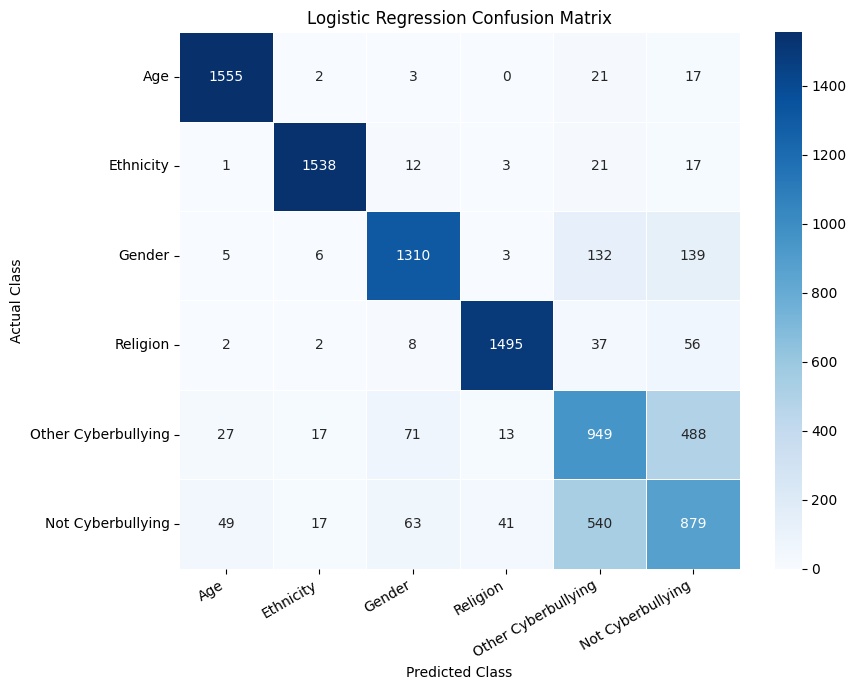

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Class names in a clean display order
class_names = [
    'Age',
    'Ethnicity',
    'Gender',
    'Religion',
    'Other Cyberbullying',
    'Not Cyberbullying'
]

# Match these to the encoded label values
label_order = le.transform([
    'age',
    'ethnicity',
    'gender',
    'religion',
    'other_cyberbullying',
    'not_cyberbullying'
])

# Confusion matrix for the best model: Logistic Regression
cm = confusion_matrix(
    y_test,
    lr_preds,
    labels=label_order
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='white',
    cbar=True
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


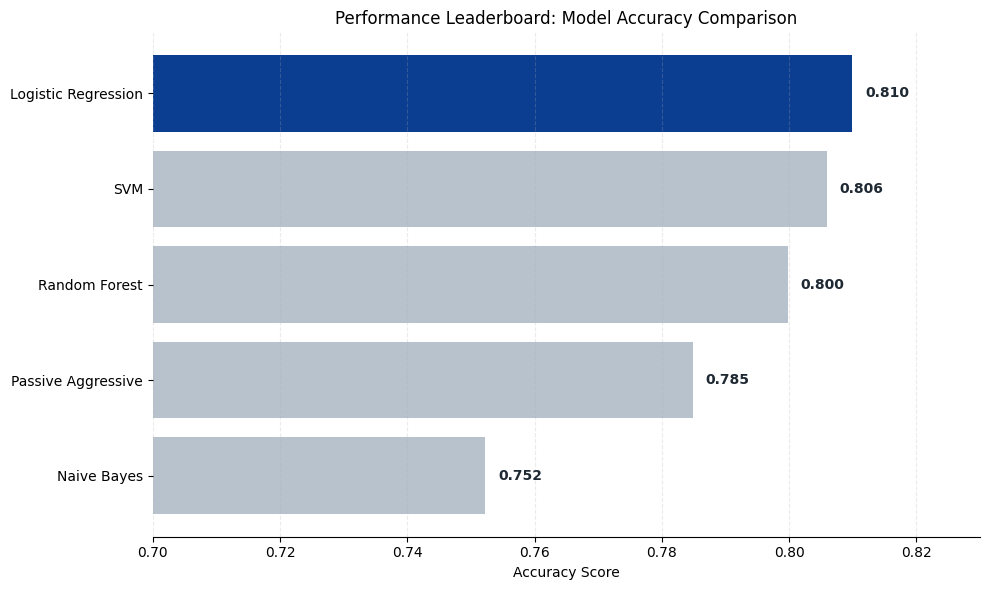

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Accuracy scores from your model evaluation results
leaderboard = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Passive Aggressive',
        'Random Forest',
        'SVM',
        'Logistic Regression',
    ],
    'Accuracy': [
        0.752280113219415,
        0.7848831114372575,
        0.799769367858266,
        0.8059545025684034,
        0.8099381486528986,
    ]
}).sort_values('Accuracy', ascending=True)

highlight_model = 'Logistic Regression'

bar_colors = [
    '#0B3D91' if model == highlight_model else '#B8C2CC'
    for model in leaderboard['Model']
]

plt.figure(figsize=(10, 6))
bars = plt.barh(
    leaderboard['Model'],
    leaderboard['Accuracy'],
    color=bar_colors
)

plt.xlim(0.70, 0.83)
plt.xlabel('Accuracy Score')
plt.title('Performance Leaderboard: Model Accuracy Comparison')
plt.grid(axis='x', linestyle='--', alpha=0.25)

plt.gca().spines[['top', 'right', 'left']].set_visible(False)

for bar, accuracy in zip(bars, leaderboard['Accuracy']):
    plt.text(
        accuracy + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{accuracy:.3f}',
        va='center',
        fontweight='bold',
        color='#1F2933'
    )

plt.tight_layout()
plt.show()


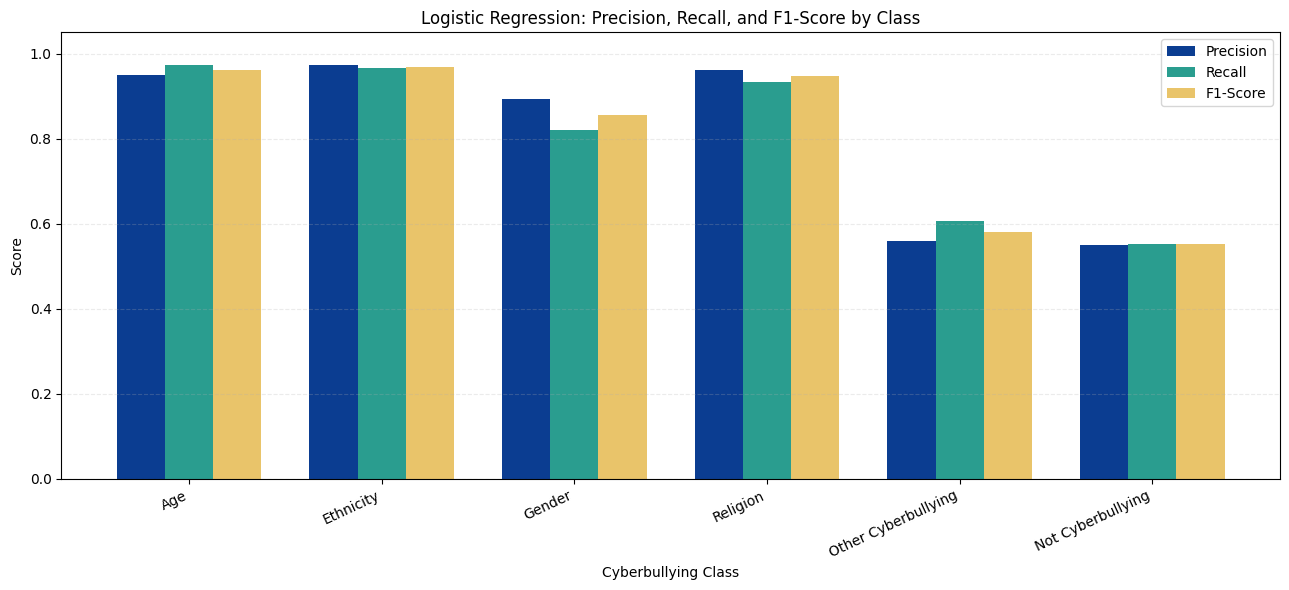

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# Generate per-class metrics for the best model: Logistic Regression
report = classification_report(
    y_test,
    lr_preds,
    target_names=le.classes_,
    output_dict=True
)

display_names = {
    'age': 'Age',
    'ethnicity': 'Ethnicity',
    'gender': 'Gender',
    'religion': 'Religion',
    'other_cyberbullying': 'Other Cyberbullying',
    'not_cyberbullying': 'Not Cyberbullying'
}

class_order = [
    'age',
    'ethnicity',
    'gender',
    'religion',
    'other_cyberbullying',
    'not_cyberbullying'
]

metrics_df = pd.DataFrame({
    'Class': [display_names[class_name] for class_name in class_order],
    'Precision': [report[class_name]['precision'] for class_name in class_order],
    'Recall': [report[class_name]['recall'] for class_name in class_order],
    'F1-Score': [report[class_name]['f1-score'] for class_name in class_order],
})

x = np.arange(len(metrics_df['Class']))
bar_width = 0.25

plt.figure(figsize=(13, 6))

plt.bar(
    x - bar_width,
    metrics_df['Precision'],
    width=bar_width,
    label='Precision',
    color='#0B3D91'
)

plt.bar(
    x,
    metrics_df['Recall'],
    width=bar_width,
    label='Recall',
    color='#2A9D8F'
)

plt.bar(
    x + bar_width,
    metrics_df['F1-Score'],
    width=bar_width,
    label='F1-Score',
    color='#E9C46A'
)

plt.title('Logistic Regression: Precision, Recall, and F1-Score by Class')
plt.xlabel('Cyberbullying Class')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(x, metrics_df['Class'], rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()
